# Notebook 3: Logistic Regression Baseline

This notebook trains and evaluates a Logistic Regression model using the engineered OULAD dataset created in Notebook 2.

The model predicts whether a student will achieve a successful outcome:

- `1` = Pass or Distinction
- `0` = Fail or Withdrawn

In [4]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [5]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [6]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root exists:", PROJECT_ROOT.exists())
print("Processed data exists:", PROCESSED_DATA_DIR.exists())

Project root exists: True
Processed data exists: True


In [7]:
DATASET_PATH = (
    PROCESSED_DATA_DIR
    / "final_modeling_dataset.csv"
)

print("Expected dataset path:")
print(DATASET_PATH)

print(
    "\nDataset exists:",
    DATASET_PATH.exists()
)

Expected dataset path:
/content/drive/MyDrive/SEAID_Framework/data/processed/final_modeling_dataset.csv

Dataset exists: True


In [8]:
student_features = pd.read_csv(
    DATASET_PATH
)

print(
    "Dataset shape:",
    student_features.shape
)

student_features.head()

Dataset shape: (32593, 81)


,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,target_success,total_clicks,...,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,registration_timing_early,registration_timing_late,registration_timing_moderately_early,registration_timing_unknown,registration_timing_very_early,registration_timing_very_late
0,AAA,2013J,11391,0,0,240,0,Pass,1,934.0,...,1,0,0,1,0,0,0,0,1,0
1,AAA,2013J,28400,1,0,60,0,Pass,1,1435.0,...,0,0,1,0,1,0,0,0,0,0
2,AAA,2013J,30268,1,0,60,1,Withdrawn,0,281.0,...,0,0,1,0,0,0,0,0,1,0
3,AAA,2013J,31604,1,0,60,0,Pass,1,2158.0,...,0,0,1,0,1,0,0,0,0,0
4,AAA,2013J,32885,1,0,60,0,Pass,1,1034.0,...,0,0,0,0,0,0,0,0,1,0


In [9]:
print(
    student_features.columns.tolist()
)

['code_module', 'code_presentation', 'id_student', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'target_success', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record', 'vle_records', 'active_days', 'unique_vle_activities', 'first_activity_day', 'last_activity_day', 'clicks_per_active_day', 'activity_span_days', 'clicks_per_vle_activity', 'log_total_clicks', 'assessments_completed', 'average_score', 'median_score', 'minimum_score', 'maximum_score', 'score_std', 'average_weight', 'total_weight_completed', 'first_submission_day', 'last_submission_day', 'banked_assessments', 'assessment_span_days', 'score_range', 'weighted_average_score', 'score_improvement', 'assessment_intensity', 'log_assessments_completed', 'date_registration', 'date_unregistration', 'registered_before_start', 'registered_after_start', 'days_registered_before_start', 'withdrew', 'days_until_withdrawal', 'early_withdrawal', 'region_East

In [10]:
TARGET = "target_success"

if TARGET not in student_features.columns:
    raise KeyError(
        f"{TARGET} is missing from the dataset."
    )

student_features[TARGET].value_counts(
    dropna=False
)

,count
target_success,
0,17208
1,15385


In [11]:
columns_to_exclude = [
    TARGET,
    "final_result",
    "id_student",
    "code_module",
    "code_presentation",
    "withdrew",
    "early_withdrawal",
    "date_unregistration",
    "days_until_withdrawal"
]

columns_to_exclude = [
    column
    for column in columns_to_exclude
    if column in student_features.columns
]

X = student_features.drop(
    columns=columns_to_exclude
)

y = student_features[TARGET].astype(int)

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (32593, 72)
Target shape: (32593,)


In [12]:
non_numeric_columns = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

print(
    "Non-numeric columns:",
    non_numeric_columns
)

Non-numeric columns: []


In [13]:
missing_values = (
    X.isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

print(
    "Total missing values:",
    missing_values.sum()
)

print(
    "Infinite values:",
    np.isinf(
        X.to_numpy(
            dtype=float
        )
    ).sum()
)

Total missing values: 0
Infinite values: 0


In [14]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

In [15]:
target_summary = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percent": (
        y.value_counts(
            normalize=True
        )
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_summary

,Count,Percent
target_success,,
0,17208,52.8
1,15385,47.2


In [16]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "Training shape:",
    X_train.shape
)

print(
    "Testing shape:",
    X_test.shape
)

Training shape: (26074, 72)
Testing shape: (6519, 72)


In [17]:
logistic_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [18]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("Cross-validation complete.")

Cross-validation complete.


In [19]:
cv_summary = pd.DataFrame({
    metric.replace("test_", ""): [
        cv_results[metric].mean(),
        cv_results[metric].std()
    ]
    for metric in cv_results
    if metric.startswith("test_")
}, index=[
    "Mean",
    "Standard Deviation"
])

cv_summary.T.round(4)

,Mean,Standard Deviation
accuracy,0.9328,0.0016
precision,0.8992,0.0033
recall,0.9660,0.0034
f1,0.9314,0.0016
roc_auc,0.9778,0.0010


## Cross-Validation Results

The Logistic Regression model demonstrated strong and consistent performance across five stratified folds.

- Mean accuracy: 93.28%
- Mean precision: 89.92%
- Mean recall: 96.60%
- Mean F1 score: 93.14%
- Mean ROC-AUC: 97.78%

The small standard deviations indicate that model performance remained stable across the five validation folds. Recall was higher than precision, suggesting that the model identified most successful students but also produced some false-positive success predictions.

In [20]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained.")

Logistic Regression model trained.


In [21]:
y_pred = logistic_pipeline.predict(
    X_test
)

y_probability = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("Test predictions generated.")

Test predictions generated.


In [22]:
test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(
            y_test,
            y_pred
        ),
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        roc_auc_score(
            y_test,
            y_probability
        )
    ]
})

test_metrics["Score"] = (
    test_metrics["Score"]
    .round(4)
)

test_metrics

,Metric,Score
0,Accuracy,0.9343
1,Precision,0.9039
2,Recall,0.9633
3,F1 Score,0.9327
4,ROC-AUC,0.9791


In [23]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

Unsuccessful       0.97      0.91      0.94      3442
  Successful       0.90      0.96      0.93      3077

    accuracy                           0.93      6519
   macro avg       0.93      0.94      0.93      6519
weighted avg       0.94      0.93      0.93      6519



## Held-Out Test Results

The Logistic Regression model performed strongly on the held-out test set.

- Accuracy: 93.43%
- Precision: 90.39%
- Recall: 96.33%
- F1 score: 93.27%
- ROC-AUC: 97.91%

These results closely align with the cross-validation estimates, suggesting that the model generalizes well to unseen data and is not showing clear evidence of overfitting. The high recall indicates that the model correctly identifies most students who achieve a successful outcome.

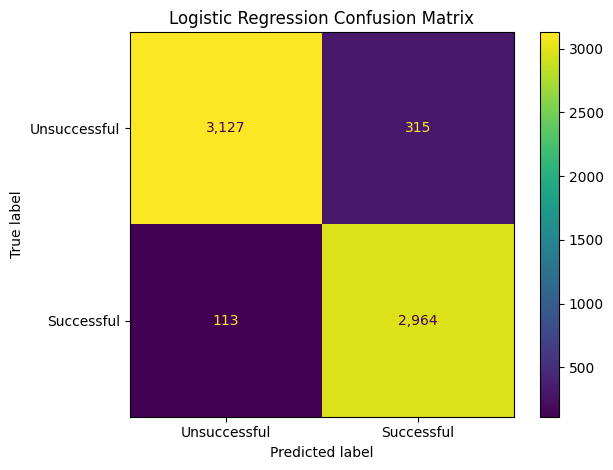

In [25]:
confusion = confusion_matrix(
    y_test,
    y_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
)

display.plot(
    values_format=","
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Classification Report

The Logistic Regression model demonstrated strong predictive performance for both outcome classes.

For unsuccessful students, the model achieved a precision of 97% and a recall of 91%, indicating that predictions of unsuccessful outcomes were highly reliable while correctly identifying most unsuccessful students.

For successful students, the model achieved a precision of 90% and a recall of 96%, indicating that the model identified nearly all successful students while producing relatively few false-positive predictions.

Overall, the balanced precision, recall, and F1 scores suggest that the model performs consistently across both classes and provides a strong baseline for comparison with more complex machine learning algorithms.